In [1]:

import glob
import io
import os
from pprint import pprint
import zipfile
from PIL import Image
import requests, json, mimetypes
import matplotlib.pyplot as plt
from settings import BASE_DIR
%matplotlib inline
URL = "http://localhost:8008/main/inpaint"
def visualize_result(translated_image, original_image_path, manga_name, is_show_result = False):
    original_image = Image.open(original_image_path)
    print(
        f"Kích thước ảnh gốc: {original_image.size}, Kích thước ảnh AI dịch: {translated_image.size}")
    # Lấy tên tập và tên file
    filename = os.path.basename(original_image_path)
    chapter = os.path.basename(os.path.dirname(original_image_path))

    # Tạo thư mục và lưu ảnh AI dịch
    ai_translated_dir = os.path.join("test_commic", "output", manga_name, "gpt_translated", chapter)
    os.makedirs(ai_translated_dir, exist_ok=True)

    ai_save_path = os.path.join(ai_translated_dir, filename)
    # Chuyển đổi từ RGBA sang RGB nếu cần
    if translated_image.mode == 'RGBA':
        translated_image = translated_image.convert('RGB')
    translated_image.save(ai_save_path)

    # Hiển thị ảnh gốc và ảnh dịch song song
    fig = plt.figure(figsize=(14, 24))  # Tăng kích thước hiển thị

    ax1 = plt.subplot(1, 3, 1)
    ax1.set_title("Ảnh gốc")
    ax1.imshow(original_image)
    ax1.axis('off')


    team_translated_path = os.path.join("test_commic", "data" , manga_name, "team_translated", chapter, filename)
    print(f"Đường dẫn ảnh dịch tay: {team_translated_path}")
    has_team_translation = os.path.exists(team_translated_path)

    if has_team_translation:
        manual_translated = Image.open(team_translated_path)
        ax2 = plt.subplot(1, 3, 2)
        ax2.set_title("Ảnh dịch tay")
        ax2.imshow(manual_translated)
        ax2.axis('off')

        ax3 = plt.subplot(1, 3, 3)
        ax3.set_title(f"AI dịch")
        ax3.imshow(translated_image)
        ax3.axis('off')
    else:
        ax2 = plt.subplot(1, 3, 2)
        ax2.set_title(f"AI dịch")
        ax2.imshow(translated_image)
        ax2.axis('off')

    # ---- Save fig ----
    compare_dir = os.path.join("test_commic", "output", manga_name, "compare", chapter)
    os.makedirs(compare_dir, exist_ok=True)
    compare_path = os.path.join(compare_dir, filename)
    plt.savefig(compare_path, dpi=200, bbox_inches='tight')
    
    # Hiển thị hình ảnh trong notebook
    if is_show_result:
        plt.show()
    
    plt.close(fig)


def run_inpaint(manga_name, chapter_number, original_image_paths, batch_size = 5, show_result = False):
    print(manga_name, chapter_number, original_image_paths)
    page_numbers = [int(path.split("/")[-1].split(".")[0]) for path in original_image_paths]
    # Sử dụng ExitStack để quản lý file handles
    from contextlib import ExitStack

    total_pages = len(original_image_paths)
    total_batches = (total_pages + batch_size - 1) // batch_size
    print(f"Tổng số trang: {total_pages}, chia thành {total_batches} batch")

    all_results = []
    
    for i in range(0, total_pages, batch_size):
        batch_paths = original_image_paths[i:i+batch_size]
        batch_numbers = page_numbers[i:i+batch_size]
        current_batch = i // batch_size + 1
        
        print(f"\nĐang xử lý batch {current_batch}/{total_batches} ({len(batch_paths)} trang)")
        
        # Tạo form data cho batch này
        batch_form_data = [
            ("target_lang", "vietnamese"),
            ("story_name", str(manga_name)),
            ("chapter_number", str(chapter_number)),
        ]
        print(batch_form_data)
        
        for n in batch_numbers:
            batch_form_data.append(("page_numbers", str(n)))
        
        # Sử dụng ExitStack để quản lý file handles
        with ExitStack() as stack:
            batch_files = [
                ("page_images", 
                (path.split("/")[-1], 
                stack.enter_context(open(path, "rb")), "image/jpeg")
                )
                for path in batch_paths
            ]
            
            # Thiết lập timeout dài hơn (5 phút)
            timeout = 3000
            
            # Gửi request cho batch hiện tại
            response = requests.post(URL, data=batch_form_data, files=batch_files, timeout=timeout)
            
            if response.status_code == 200:
                # Xử lý file ZIP
                with zipfile.ZipFile(io.BytesIO(response.content)) as zip_file:
                    # Lấy danh sách các file trong ZIP
                    file_names = zip_file.namelist()
                    print(file_names)
                    print(f"Nhận được {len(file_names)} file từ batch {current_batch}")
                    
                    for file_name, original_image_path in zip(file_names, batch_paths):
                        # Đọc từng file trong ZIP
                        with zip_file.open(file_name) as file:
                            # Chuyển đổi thành đối tượng Image
                            translated_image = Image.open(file)
                            # Gọi hàm visualize cho từng ảnh
                            visualize_result(translated_image, original_image_path, manga_name, is_show_result=show_result)
            else:
                print(f"Lỗi batch {current_batch}: {response.status_code}")
                print(response.text)


In [ ]:
THIS IS OUR TREASURED
DISH, THE RED WATER
MAP HOTPOT
ĐÂY LÀ MÓN TRÂN PHẨM
CỦA QUÁN, HỒNG THỦY NGƯ ĐỒLẨU

Yule 134 ['/home/aorus/workspaces/magiv2/test_commic/data/Yule/Raw/134/8.jpg']
Tổng số trang: 1, chia thành 1 batch

Đang xử lý batch 1/1 (1 trang)
[('target_lang', 'vietnamese'), ('story_name', 'Yule'), ('chapter_number', '134')]
['8.png']
Nhận được 1 file từ batch 1
Kích thước ảnh gốc: (1000, 2380), Kích thước ảnh AI dịch: (1000, 2380)
Đường dẫn ảnh dịch tay: test_commic/data/Yule/team_translated/134/8.jpg


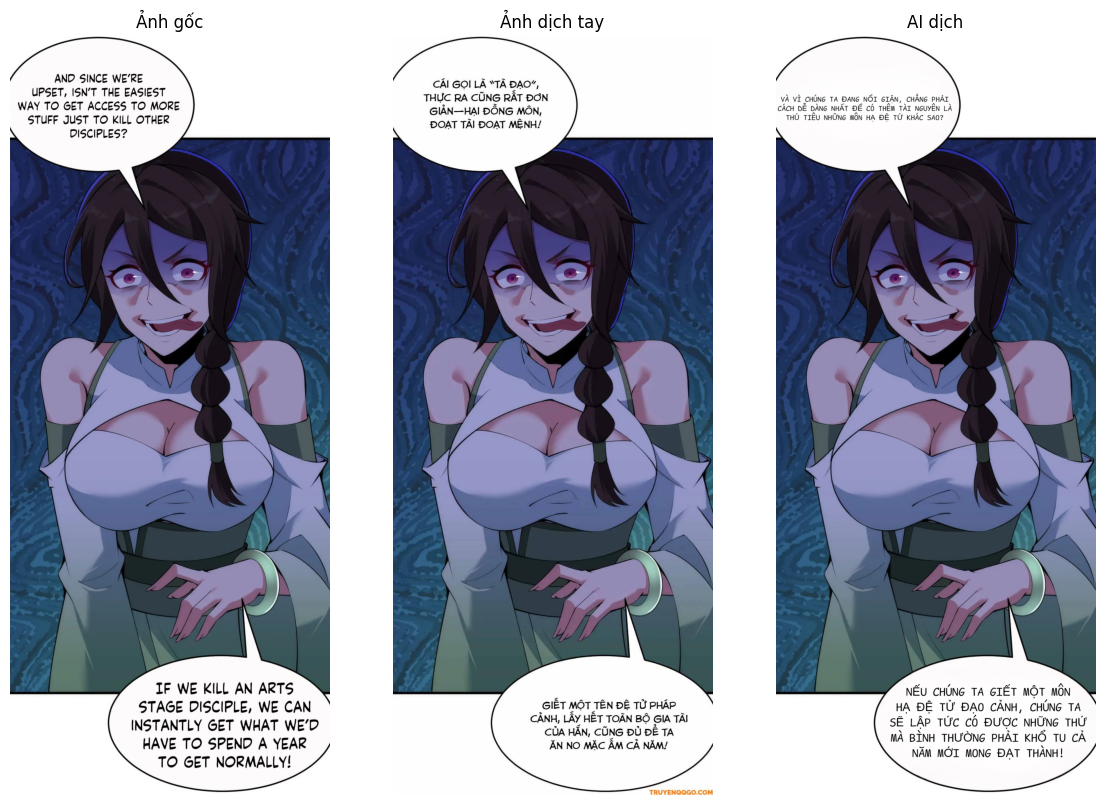

In [5]:
CHAPTER_NUMBER = 134
PAGE_NUMBER = 8
MANGA_NAME = "Yule"
folder_path = f"{BASE_DIR}/test_commic/data/{MANGA_NAME}"
chapter_folder_path = os.path.join(folder_path, "Raw", str(CHAPTER_NUMBER))
original_image_paths = [f"{BASE_DIR}/test_commic/data/Yule/Raw/{CHAPTER_NUMBER}/{PAGE_NUMBER}.jpg"]
run_inpaint(MANGA_NAME, CHAPTER_NUMBER, original_image_paths, batch_size=11, show_result=True)


In [5]:
from utils.utils import bbox_to_quad

bbox_to_quad(test_bboxes[0])

array([[[   0.        ,   80.50917053],
        [ 761.48962402,   80.50917053],
        [ 761.48962402,  299.39590454],
        [   0.        ,  299.39590454]],

       [[ 187.38969421, 2081.58398438],
        [ 999.        , 2081.58398438],
        [ 999.        , 2182.42236328],
        [ 187.38969421, 2182.42236328]],

       [[   0.        , 2870.49072266],
        [ 750.60205078, 2870.49072266],
        [ 750.60205078, 3230.95507812],
        [   0.        , 3230.95507812]],

       [[   0.        , 4316.24609375],
        [ 562.27661133, 4316.24609375],
        [ 562.27661133, 4558.85449219],
        [   0.        , 4558.85449219]]])

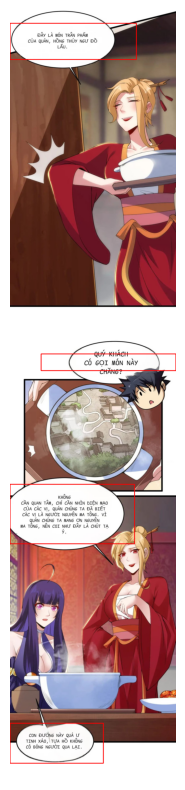

In [7]:
import cv2

test_bboxes = [[[0.0, 80.50917053222656, 761.4896240234375, 299.3959045410156],
  [187.3896942138672, 2081.583984375, 999.0, 2182.42236328125],
  [0.0, 2870.49072265625, 750.60205078125, 3230.955078125],
  [0.0, 4316.24609375, 562.276611328125, 4558.8544921875]]]

img_path = "/home/aorus/workspaces/magiv2/test_commic/output/Yule/gpt_translated/133/7.jpg"
image = cv2.imread(img_path)

# Convert BGR (OpenCV) to RGB (matplotlib)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Draw bounding boxes
for box in test_bboxes[0]:
    x1, y1, x2, y2 = map(int, box)
    cv2.rectangle(image, (x1, y1), (x2, y2), color=(255, 0, 0), thickness=4)

# Show image
plt.figure(figsize=(10, 10))
plt.imshow(image)
plt.axis("off")
plt.show()

### Debug Text Render ENG

ModuleNotFoundError: No module named 'hyphen.textwrap2'

ModuleNotFoundError: No module named 'py3langid'

In [6]:
chapter_number = 134
manga_name = "Yule"
folder_path = f"/home/aorus/workspaces/test_commic/data/{manga_name}"
chapter_folder_path = os.path.join(folder_path, "Raw", str(chapter_number))
original_image_paths = glob.glob(os.path.join(chapter_folder_path, "*.jpg"))
run_inpaint(manga_name, chapter_number, original_image_paths, batch_size=10)

Yule 134 ['/home/aorus/workspaces/test_commic/data/Yule/Raw/134/17.jpg', '/home/aorus/workspaces/test_commic/data/Yule/Raw/134/11.jpg', '/home/aorus/workspaces/test_commic/data/Yule/Raw/134/23.jpg', '/home/aorus/workspaces/test_commic/data/Yule/Raw/134/7.jpg', '/home/aorus/workspaces/test_commic/data/Yule/Raw/134/22.jpg', '/home/aorus/workspaces/test_commic/data/Yule/Raw/134/18.jpg', '/home/aorus/workspaces/test_commic/data/Yule/Raw/134/3.jpg', '/home/aorus/workspaces/test_commic/data/Yule/Raw/134/19.jpg', '/home/aorus/workspaces/test_commic/data/Yule/Raw/134/9.jpg', '/home/aorus/workspaces/test_commic/data/Yule/Raw/134/12.jpg', '/home/aorus/workspaces/test_commic/data/Yule/Raw/134/13.jpg', '/home/aorus/workspaces/test_commic/data/Yule/Raw/134/5.jpg', '/home/aorus/workspaces/test_commic/data/Yule/Raw/134/20.jpg', '/home/aorus/workspaces/test_commic/data/Yule/Raw/134/14.jpg', '/home/aorus/workspaces/test_commic/data/Yule/Raw/134/1.jpg', '/home/aorus/workspaces/test_commic/data/Yule/Raw/

In [7]:
chapter_numbers = [134, 135, 136, 137]
for chapter_number in chapter_numbers:
    manga_name = "Yule"
    folder_path = f"/home/aorus/workspaces/test_commic/data/{manga_name}"
    chapter_folder_path = os.path.join(folder_path, "Raw", str(chapter_number))
    original_image_paths = glob.glob(os.path.join(chapter_folder_path, "*.jpg"))
    run_inpaint(manga_name, chapter_number, original_image_paths, batch_size=10)

Yule 134 ['/home/aorus/workspaces/test_commic/data/Yule/Raw/134/17.jpg', '/home/aorus/workspaces/test_commic/data/Yule/Raw/134/11.jpg', '/home/aorus/workspaces/test_commic/data/Yule/Raw/134/23.jpg', '/home/aorus/workspaces/test_commic/data/Yule/Raw/134/7.jpg', '/home/aorus/workspaces/test_commic/data/Yule/Raw/134/22.jpg', '/home/aorus/workspaces/test_commic/data/Yule/Raw/134/18.jpg', '/home/aorus/workspaces/test_commic/data/Yule/Raw/134/3.jpg', '/home/aorus/workspaces/test_commic/data/Yule/Raw/134/19.jpg', '/home/aorus/workspaces/test_commic/data/Yule/Raw/134/9.jpg', '/home/aorus/workspaces/test_commic/data/Yule/Raw/134/12.jpg', '/home/aorus/workspaces/test_commic/data/Yule/Raw/134/13.jpg', '/home/aorus/workspaces/test_commic/data/Yule/Raw/134/5.jpg', '/home/aorus/workspaces/test_commic/data/Yule/Raw/134/20.jpg', '/home/aorus/workspaces/test_commic/data/Yule/Raw/134/14.jpg', '/home/aorus/workspaces/test_commic/data/Yule/Raw/134/1.jpg', '/home/aorus/workspaces/test_commic/data/Yule/Raw/